Saving letter-case-z-english-alphabet-png-favpng-n9JxLnaCQ4CJLw9xDPfhgtHE1.jpg to letter-case-z-english-alphabet-png-favpng-n9JxLnaCQ4CJLw9xDPfhgtHE1.jpg
Image loaded: letter-case-z-english-alphabet-png-favpng-n9JxLnaCQ4CJLw9xDPfhgtHE1.jpg


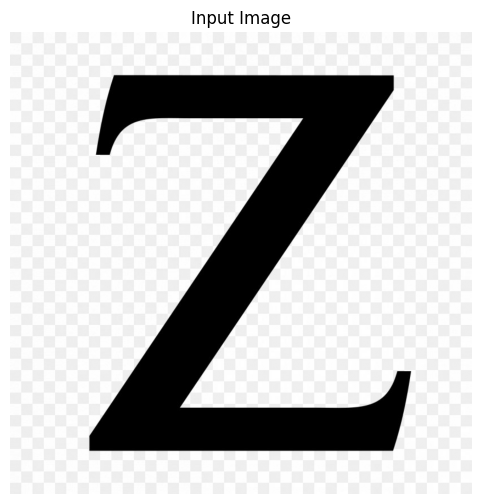

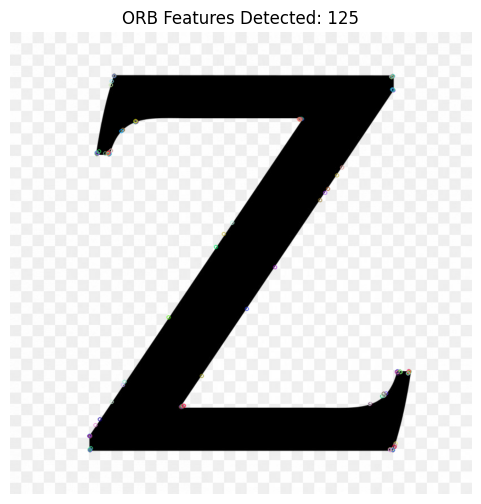

ORB Descriptor Shape: (125, 32)


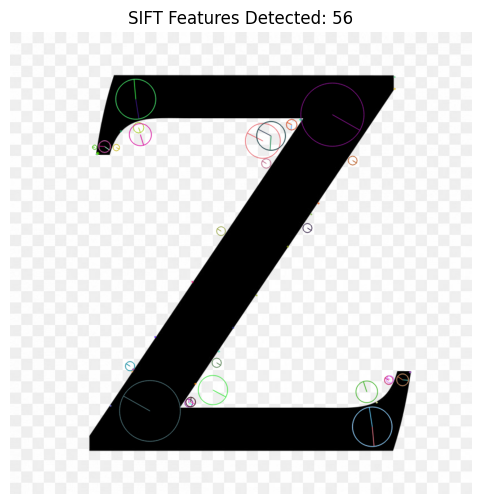

SIFT Descriptor Shape: (56, 128)
❌ SURF not supported (Patent restriction in OpenCV)
===== FEATURE EXTRACTION SUMMARY =====
ORB Features  : 125
SIFT Features : 56


In [ ]:
# =========================================
# Feature Extraction and Feature Detection
# ORB  = Oriented FAST and Rotated BRIEF
# SIFT = Scale-Invariant Feature Transform
# SURF = Speeded-Up Robust Features
# =========================================

import cv2
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print("Image loaded:", image_path)

# Read image
img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Display input image
plt.figure(figsize=(6,6))
plt.imshow(gray, cmap='gray')
plt.title("Input Image")
plt.axis("off")
plt.show()

# =========================
# ORB Feature Detection
# =========================
orb = cv2.ORB_create(nfeatures=500)
kp_orb, des_orb = orb.detectAndCompute(gray, None)

orb_img = cv2.drawKeypoints(
    gray, kp_orb, None,
    flags=cv2.DrawMatchesFlags_DEFAULT
)

plt.figure(figsize=(6,6))
plt.imshow(orb_img, cmap='gray')
plt.title(f"ORB Features Detected: {len(kp_orb)}")
plt.axis("off")
plt.show()

print("ORB Descriptor Shape:", des_orb.shape)

# =========================
# SIFT Feature Detection
# =========================
sift = cv2.SIFT_create()
kp_sift, des_sift = sift.detectAndCompute(gray, None)

sift_img = cv2.drawKeypoints(
    gray, kp_sift, None,
    flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(6,6))
plt.imshow(sift_img, cmap='gray')
plt.title(f"SIFT Features Detected: {len(kp_sift)}")
plt.axis("off")
plt.show()

print("SIFT Descriptor Shape:", des_sift.shape)

# =========================
# SURF Feature Detection
# =========================
try:
    surf = cv2.xfeatures2d.SURF_create(400)
    kp_surf, des_surf = surf.detectAndCompute(gray, None)

    surf_img = cv2.drawKeypoints(
        gray, kp_surf, None,
        flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS
    )

    plt.figure(figsize=(6,6))
    plt.imshow(surf_img, cmap='gray')
    plt.title(f"SURF Features Detected: {len(kp_surf)}")
    plt.axis("off")
    plt.show()

    print("SURF Descriptor Shape:", des_surf.shape)

except:
    print("❌ SURF not supported (Patent restriction in OpenCV)")

# =========================
# Summary
# =========================
print("===== FEATURE EXTRACTION SUMMARY =====")
print("ORB Features  :", len(kp_orb))
print("SIFT Features :", len(kp_sift))
